In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import sys
sys.path.insert(0, '..')
from src import EmbeddedInterpolants, sliced_wasserstein1, distributions

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

np.random.seed(8)
%matplotlib inline
plt.rcParams['figure.dpi'] = 130

def sw1(X, Y):
    X = X.reshape(-1, X.shape[-1]) if X.ndim > 1 else X.reshape(-1,1)
    Y = Y.reshape(-1, Y.shape[-1]) if Y.ndim > 1 else Y.reshape(-1,1)
    return sliced_wasserstein1(X, Y)

In [25]:
def fit_with_traces(model, X_src, X_tgt, n_iter):
    """Mirrors EmbeddedInterpolants.fit() but stores per-step particle states."""
    Y_init  = np.vstack([X_src, X_tgt])
    decay_q = (model.sigma_k is None
               and model.bandwidth_method == "quantile"
               and model.q_final != model.q)
    model._sigma           = model._select_bandwidth(Y_init, q=model.q)
    model._sigmas          = []
    model._velocity_fields = []

    x          = X_src.copy()
    step_parts = [x.copy()]
    iter_bnd   = [0]

    for it in range(1, n_iter + 1):
        a       = (it - 1) / max(n_iter - 1, 1)
        gamma_t = (1 - a) * model.gamma + a * model.gamma_final
        q_t     = (1 - a) * model.q     + a * model.q_final
        if decay_q:
            model._sigma = model._select_bandwidth(Y_init, q=q_t)
        model._sigmas.append(model._sigma)

        Ns     = min(len(x), model.N_src_max)
        idx    = np.random.choice(len(x), Ns, replace=False)
        fv, ot = model._build(x[idx], X_tgt, gamma=gamma_t)
        model._velocity_fields.append((fv, ot))

        res = model._integrate(x, fv, ot, store_traj=True)
        for k in range(1, res["trajectories"].shape[0]):
            step_parts.append(res["trajectories"][k])
        iter_bnd.append(len(step_parts) - 1)
        x = res["particles"]

    model._fitted     = True
    model._fit_result = {"particles": x,
                         "snapshots": step_parts[::model.K_steps],
                         "sigmas": list(model._sigmas)}
    return step_parts, iter_bnd


def transport_with_traces(model, x_new):
    """Mirrors EmbeddedInterpolants.transport() but stores per-step particle states."""
    x          = x_new.copy()
    step_parts = [x.copy()]
    iter_bnd   = [0]
    for fv, ot in model._velocity_fields:
        res = model._integrate(x, fv, ot, store_traj=True)
        for k in range(1, res["trajectories"].shape[0]):
            step_parts.append(res["trajectories"][k])
        iter_bnd.append(len(step_parts) - 1)
        x = res["particles"]
    return step_parts, iter_bnd

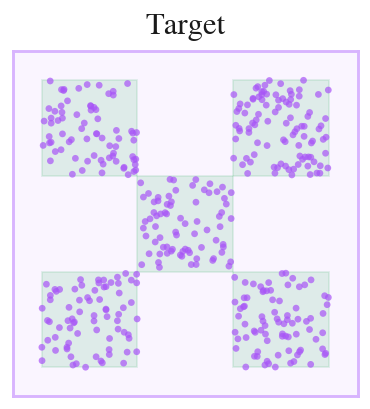

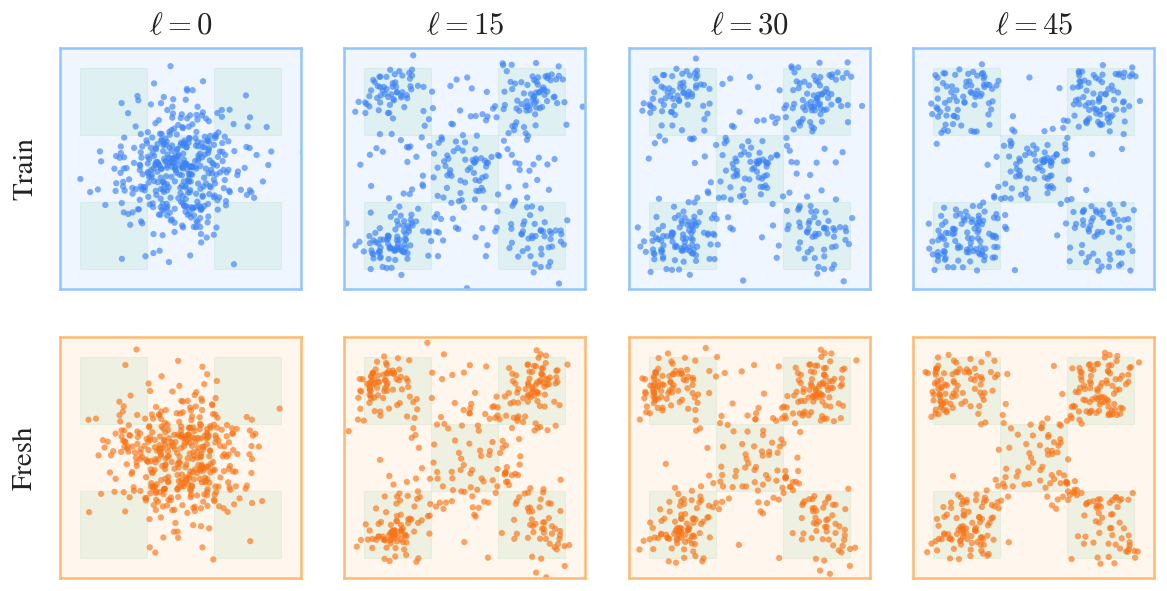

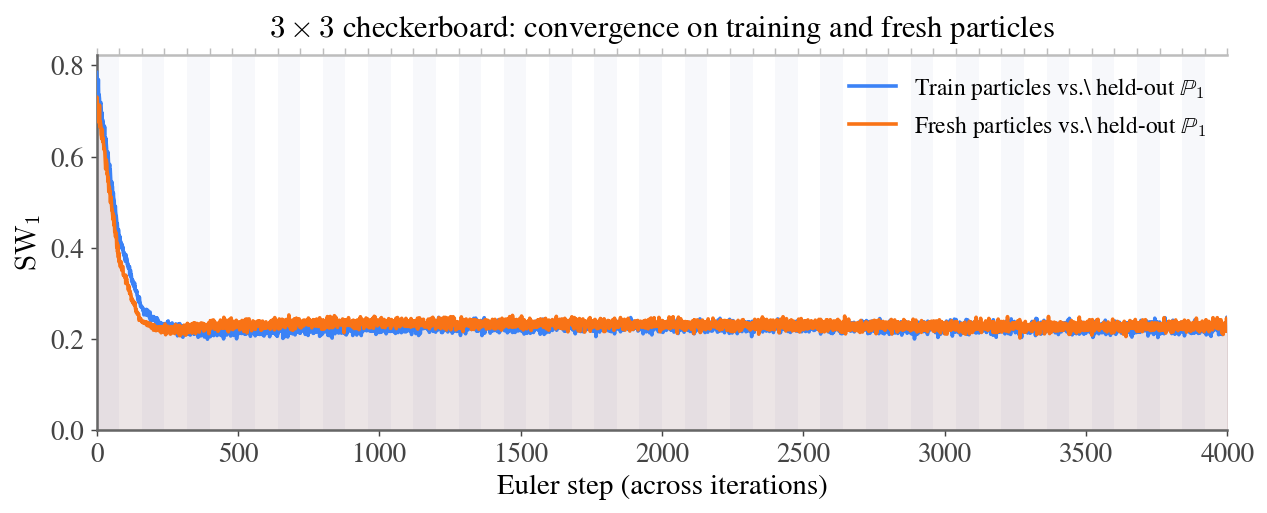

In [28]:
# ─── 1. Checkerboard setup (from user) ───────────────────────────────
csz, off = 2.0, -3.0
cells = [(off + j * csz, off + i * csz)
         for i in range(3) for j in range(3) if (i + j) % 2 == 0]

def sample_board(n):
    K = len(cells); s = np.zeros((n, 2))
    lab = np.random.randint(0, K, n)
    for idx, (xl, yl) in enumerate(cells):
        m = lab == idx
        s[m, 0] = np.random.uniform(xl, xl + csz, m.sum())
        s[m, 1] = np.random.uniform(yl, yl + csz, m.sum())
    return s

N_train = N_fresh = 400
N_data  = 400
N_held  = 400

X1_b      = sample_board(N_data)
x_true_b  = sample_board(N_held)

model_b = EmbeddedInterpolants(
    sigma_k=None, gamma=0.01, gamma_final=1e-8, K_steps=80,
    N_src_max=10000, rescale=False, noise_level=1.1,
    n_inducing=200, q=0.5, q_final=0.05)


# ─── 2. Run with traces ──────────────────────────────────────────────
step_parts_train_b, iter_bnd_b = fit_with_traces(
    model_b, np.random.randn(N_train, 2), X1_b, n_iter=50)

step_parts_fresh_b, _ = transport_with_traces(
    model_b, np.random.randn(N_fresh, 2))

sw_train_b = np.array([sw1(p, x_true_b) for p in step_parts_train_b])
sw_fresh_b = np.array([sw1(p, x_true_b) for p in step_parts_fresh_b])


# ─── 3. Toonish style ────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['CMU Serif', 'Computer Modern Roman',
                          'STIXGeneral', 'DejaVu Serif'],
    'mathtext.fontset':  'cm',
    'mathtext.rm':       'serif',
    'mathtext.it':       'serif:italic',
    'font.size':         15,
    'axes.titlesize':    17,
    'axes.labelsize':    16,
    'axes.linewidth':    1.4,
    'savefig.dpi':       300,
})

C_TRAIN_DOT,  C_TRAIN_BG,  C_TRAIN_EDGE  = '#3b82f6', '#eff6ff', '#93c5fd'
C_FRESH_DOT,  C_FRESH_BG,  C_FRESH_EDGE  = '#f97316', '#fff7ed', '#fdba74'
C_TARGET_DOT, C_TARGET_BG, C_TARGET_EDGE = '#a855f7', '#faf5ff', '#d8b4fe'
C_BOARD                                  = '#16a34a'

XL, YL = (-3.6, 3.6), (-3.6, 3.6)

def style_panel(ax, bg, edge, lw=1.4):
    ax.set_xlim(*XL); ax.set_ylim(*YL)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor(bg)
    for s in ax.spines.values():
        s.set_edgecolor(edge); s.set_linewidth(lw)

def draw_board(ax, alpha_fill=0.10, alpha_edge=0.5, lw=0.8):
    for xl, yl in cells:
        ax.add_patch(Rectangle((xl, yl), csz, csz,
                               fill=True, fc=C_BOARD, alpha=alpha_fill,
                               ec=C_BOARD, lw=lw, zorder=0))


# ════════════════════════════════════════════════════════════════════
# FIGURE 1  ── target alone ─────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(3.4, 3.4), facecolor='white')
draw_board(ax, alpha_fill=0.12, lw=1.0)
ax.scatter(x_true_b[:, 0], x_true_b[:, 1],
           s=14, alpha=0.7, c=C_TARGET_DOT, edgecolors='none', zorder=2)
style_panel(ax, C_TARGET_BG, C_TARGET_EDGE, lw=1.6)
ax.set_title(r'Target', pad=10, color='#1a1a1a')
plt.tight_layout(); plt.show()


# ════════════════════════════════════════════════════════════════════
# FIGURE 2  ── 2×4 snapshot grid: Train / Fresh ─────────────────────
# ════════════════════════════════════════════════════════════════════
iters  = [0, 15, 30, 45]
n_cols = len(iters)

train_snaps = [step_parts_train_b[iter_bnd_b[i]] for i in range(len(iter_bnd_b))]
fresh_snaps = [step_parts_fresh_b[iter_bnd_b[i]] for i in range(len(iter_bnd_b))]

fig = plt.figure(figsize=(9.4, 4.8), facecolor='white')
gs  = GridSpec(2, n_cols, hspace=0.20, wspace=0.10,
               left=0.07, right=0.98, top=0.90, bottom=0.05)

for row_idx, snaps, dot, bg, edge, label in [
    (0, train_snaps, C_TRAIN_DOT, C_TRAIN_BG, C_TRAIN_EDGE, 'Train'),
    (1, fresh_snaps, C_FRESH_DOT, C_FRESH_BG, C_FRESH_EDGE, 'Fresh'),
]:
    for col, it in enumerate(iters):
        ax = fig.add_subplot(gs[row_idx, col])
        draw_board(ax, alpha_fill=0.07, alpha_edge=0.35, lw=0.6)
        ax.scatter(snaps[it][:, 0], snaps[it][:, 1],
                   s=12, alpha=0.65, c=dot, edgecolors='none', zorder=2)
        style_panel(ax, bg, edge)
        if row_idx == 0:
            txt = r'$\ell = 0$' if it == 0 else fr'$\ell = {it}$'
            ax.set_title(txt, pad=8, color='#222222')
        if col == 0:
            ax.set_ylabel(label, rotation=90, labelpad=12, color='#222222')

plt.show()


# ════════════════════════════════════════════════════════════════════
# FIGURE 3  ── SW1 curves over Euler steps ──────────────────────────
# ════════════════════════════════════════════════════════════════════
xs = np.arange(len(step_parts_train_b))

fig, ax = plt.subplots(figsize=(10, 4.2), facecolor='white')

for i in range(len(iter_bnd_b) - 1):
    if i % 2 == 0:
        ax.axvspan(iter_bnd_b[i], iter_bnd_b[i + 1],
                   color='#f7f8fb', zorder=0, lw=0)

ax.fill_between(xs, sw_train_b, color=C_TRAIN_DOT, alpha=0.10, zorder=2)
ax.plot(xs, sw_train_b, color=C_TRAIN_DOT, lw=2.0, zorder=4,
        label=r'Train particles vs.\ held-out $\mathbb{P}_1$')

ax.fill_between(xs, sw_fresh_b, color=C_FRESH_DOT, alpha=0.10, zorder=2)
ax.plot(xs, sw_fresh_b, color=C_FRESH_DOT, lw=2.0, zorder=4,
        label=r'Fresh particles vs.\ held-out $\mathbb{P}_1$')

sec = ax.secondary_xaxis('top')
sec.set_xticks(iter_bnd_b)
sec.set_xticklabels([])
sec.tick_params(length=4, color='#bdbdbd')
sec.spines['top'].set_color('#bdbdbd')

ax.set_xlim(0, xs[-1])
ax.set_ylim(0, max(sw_train_b.max(), sw_fresh_b.max()) * 1.05)
ax.set_xlabel('Euler step (across iterations)')
ax.set_ylabel(r'$\mathrm{SW}_1$')
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color('#666666')
ax.spines['bottom'].set_color('#666666')
ax.tick_params(colors='#444444')
ax.legend(loc='upper right', frameon=False, fontsize=13)
ax.set_title(r'$3\times 3$ checkerboard: convergence on training and fresh particles',
             pad=10)

plt.tight_layout()
plt.show()


Train SW1 (final) = 0.041
Fresh SW1 (final) = 0.064


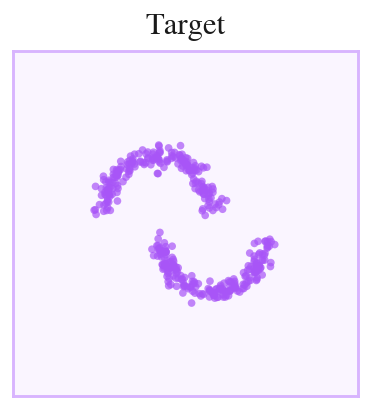

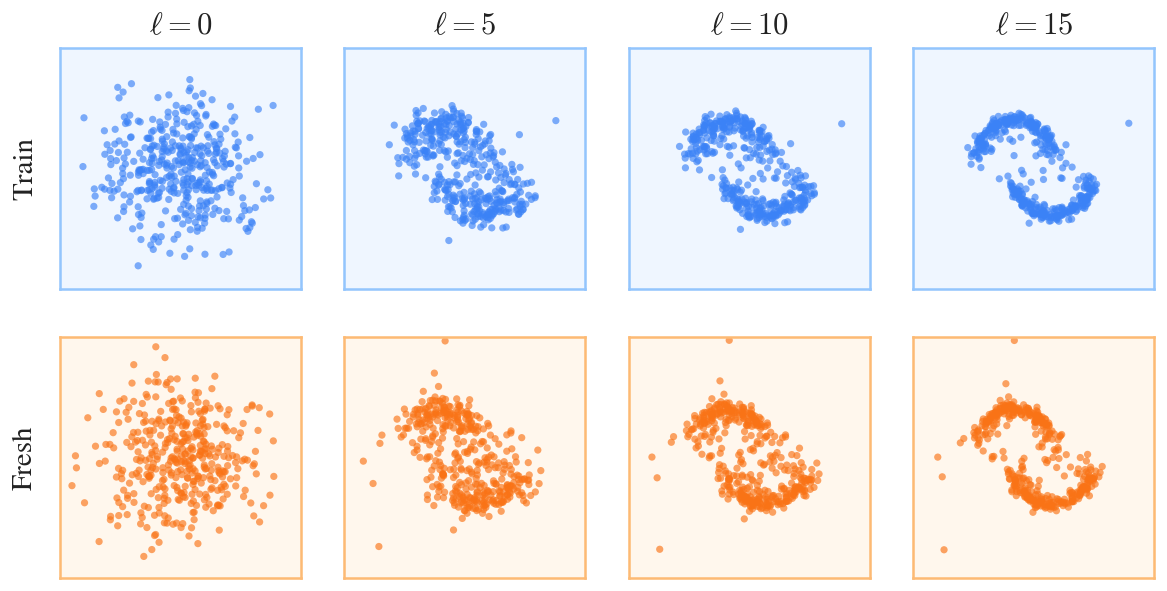

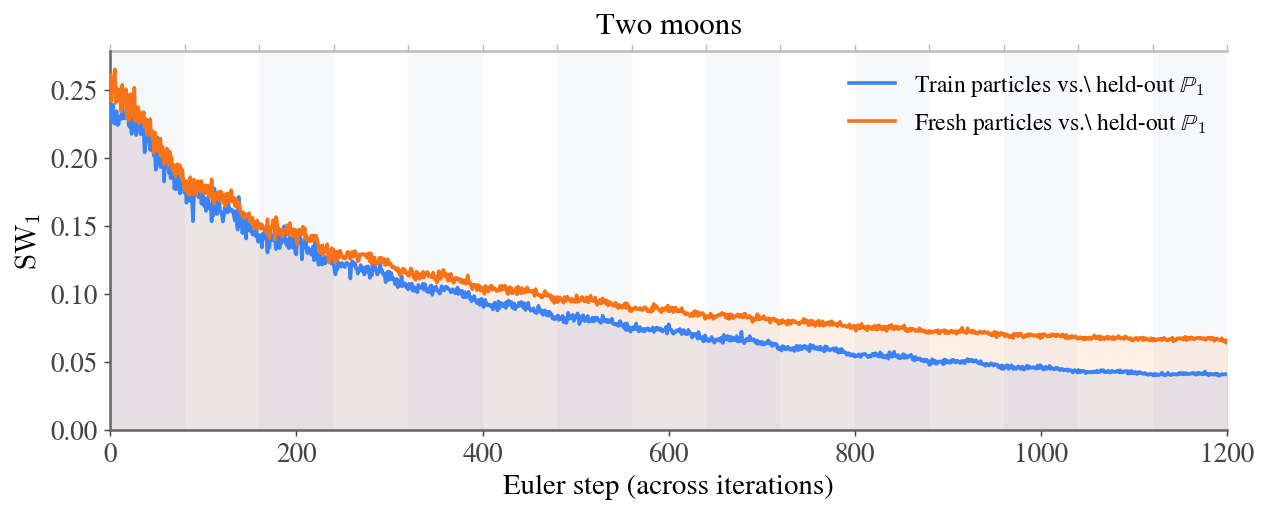

In [27]:
# ════════════════════════════════════════════════════════════════════
# 1. Trace helpers (per-Euler-step particle states)
# ════════════════════════════════════════════════════════════════════
def fit_with_traces(model, X_src, X_tgt, n_iter):
    """Mirrors EmbeddedInterpolants.fit() but stores per-step states."""
    Y_init  = np.vstack([X_src, X_tgt])
    decay_q = (model.sigma_k is None
               and model.bandwidth_method == "quantile"
               and model.q_final != model.q)
    model._sigma           = model._select_bandwidth(Y_init, q=model.q)
    model._sigmas          = []
    model._velocity_fields = []

    x          = X_src.copy()
    step_parts = [x.copy()]
    iter_bnd   = [0]

    for it in range(1, n_iter + 1):
        a       = (it - 1) / max(n_iter - 1, 1)
        gamma_t = (1 - a) * model.gamma + a * model.gamma_final
        q_t     = (1 - a) * model.q     + a * model.q_final
        if decay_q:
            model._sigma = model._select_bandwidth(Y_init, q=q_t)
        model._sigmas.append(model._sigma)

        Ns     = min(len(x), model.N_src_max)
        idx    = np.random.choice(len(x), Ns, replace=False)
        fv, ot = model._build(x[idx], X_tgt, gamma=gamma_t)
        model._velocity_fields.append((fv, ot))

        res = model._integrate(x, fv, ot, store_traj=True)
        for k in range(1, res["trajectories"].shape[0]):
            step_parts.append(res["trajectories"][k])
        iter_bnd.append(len(step_parts) - 1)
        x = res["particles"]

    model._fitted     = True
    model._fit_result = {"particles": x,
                         "snapshots": step_parts[::model.K_steps],
                         "sigmas": list(model._sigmas)}
    return step_parts, iter_bnd


def transport_with_traces(model, x_new):
    x          = x_new.copy()
    step_parts = [x.copy()]
    iter_bnd   = [0]
    for fv, ot in model._velocity_fields:
        res = model._integrate(x, fv, ot, store_traj=True)
        for k in range(1, res["trajectories"].shape[0]):
            step_parts.append(res["trajectories"][k])
        iter_bnd.append(len(step_parts) - 1)
        x = res["particles"]
    return step_parts, iter_bnd


# ════════════════════════════════════════════════════════════════════
# 2. Data + model
# ════════════════════════════════════════════════════════════════════
np.random.seed(0)

N_train = N_fresh = 400
N_data  = 400
N_held  = 400
N_ITER  = 15

X1_2d     = distributions.two_moons(N_data)
x_true_2d = distributions.two_moons(N_held)

model_2d = EmbeddedInterpolants(
    sigma_k=None, gamma=0.01, gamma_final=1e-9, K_steps=80,
    N_src_max=10000, n_inducing=100, noise_level=1.0,
    q=0.5, q_final=0.1, rescale=False)


# ════════════════════════════════════════════════════════════════════
# 3. Run
# ════════════════════════════════════════════════════════════════════
step_parts_train, iter_bnd = fit_with_traces(
    model_2d, np.random.randn(N_train, 2), X1_2d, n_iter=N_ITER)

step_parts_fresh, _ = transport_with_traces(
    model_2d, np.random.randn(N_fresh, 2))

sw_train = np.array([sw1(p, x_true_2d) for p in step_parts_train])
sw_fresh = np.array([sw1(p, x_true_2d) for p in step_parts_fresh])

print(f'\nTrain SW1 (final) = {sw_train[-1]:.3f}')
print(f'Fresh SW1 (final) = {sw_fresh[-1]:.3f}')


# ════════════════════════════════════════════════════════════════════
# 4. Plotting style
# ════════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['CMU Serif', 'Computer Modern Roman',
                          'STIXGeneral', 'DejaVu Serif'],
    'mathtext.fontset':  'cm',
    'mathtext.rm':       'serif',
    'mathtext.it':       'serif:italic',
    'font.size':         15,
    'axes.titlesize':    17,
    'axes.labelsize':    16,
    'axes.linewidth':    1.4,
    'savefig.dpi':       300,
})

C_TRAIN_DOT,  C_TRAIN_BG,  C_TRAIN_EDGE  = '#3b82f6', '#eff6ff', '#93c5fd'
C_FRESH_DOT,  C_FRESH_BG,  C_FRESH_EDGE  = '#f97316', '#fff7ed', '#fdba74'
C_TARGET_DOT, C_TARGET_BG, C_TARGET_EDGE = '#a855f7', '#faf5ff', '#d8b4fe'

XL, YL = (-3.2, 3.2), (-3.2, 3.2)


def style_panel(ax, bg, edge, lw=1.4):
    ax.set_xlim(*XL); ax.set_ylim(*YL)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor(bg)
    for s in ax.spines.values():
        s.set_edgecolor(edge); s.set_linewidth(lw)


# ════════════════════════════════════════════════════════════════════
# 5. FIGURE 1  ── target
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(3.4, 3.4), facecolor='white')
ax.scatter(x_true_2d[:, 0], x_true_2d[:, 1],
           s=18, alpha=0.7, c=C_TARGET_DOT, edgecolors='none')
style_panel(ax, C_TARGET_BG, C_TARGET_EDGE, lw=1.6)
ax.set_title('Target', pad=10, color='#1a1a1a')
plt.tight_layout(); plt.show()


# ════════════════════════════════════════════════════════════════════
# 6. FIGURE 2  ── 2×4 snapshot grid
# ════════════════════════════════════════════════════════════════════
iters  = [0, 5, 10, 15]
n_cols = len(iters)

train_snaps = [step_parts_train[iter_bnd[i]] for i in range(len(iter_bnd))]
fresh_snaps = [step_parts_fresh[iter_bnd[i]] for i in range(len(iter_bnd))]

fig = plt.figure(figsize=(9.4, 4.8), facecolor='white')
gs  = GridSpec(2, n_cols, hspace=0.20, wspace=0.10,
               left=0.07, right=0.98, top=0.90, bottom=0.05)

for row_idx, snaps, dot, bg, edge, label in [
    (0, train_snaps, C_TRAIN_DOT, C_TRAIN_BG, C_TRAIN_EDGE, 'Train'),
    (1, fresh_snaps, C_FRESH_DOT, C_FRESH_BG, C_FRESH_EDGE, 'Fresh'),
]:
    for col, it in enumerate(iters):
        ax = fig.add_subplot(gs[row_idx, col])
        ax.scatter(snaps[it][:, 0], snaps[it][:, 1],
                   s=16, alpha=0.65, c=dot, edgecolors='none')
        style_panel(ax, bg, edge)
        if row_idx == 0:
            txt = r'$\ell = 0$' if it == 0 else fr'$\ell = {it}$'
            ax.set_title(txt, pad=8, color='#222222')
        if col == 0:
            ax.set_ylabel(label, rotation=90, labelpad=12, color='#222222')

plt.show()


# ════════════════════════════════════════════════════════════════════
# 7. FIGURE 3  ── SW1 curves
# ════════════════════════════════════════════════════════════════════
xs = np.arange(len(step_parts_train))

fig, ax = plt.subplots(figsize=(10, 4.2), facecolor='white')

for i in range(len(iter_bnd) - 1):
    if i % 2 == 0:
        ax.axvspan(iter_bnd[i], iter_bnd[i + 1],
                   color='#f7f8fb', zorder=0, lw=0)

ax.fill_between(xs, sw_train, color=C_TRAIN_DOT, alpha=0.10, zorder=2)
ax.plot(xs, sw_train, color=C_TRAIN_DOT, lw=2.0, zorder=4,
        label=r'Train particles vs.\ held-out $\mathbb{P}_1$')

ax.fill_between(xs, sw_fresh, color=C_FRESH_DOT, alpha=0.10, zorder=2)
ax.plot(xs, sw_fresh, color=C_FRESH_DOT, lw=2.0, zorder=4,
        label=r'Fresh particles vs.\ held-out $\mathbb{P}_1$')

sec = ax.secondary_xaxis('top')
sec.set_xticks(iter_bnd)
sec.set_xticklabels([])
sec.tick_params(length=4, color='#bdbdbd')
sec.spines['top'].set_color('#bdbdbd')

ax.set_xlim(0, xs[-1])
ax.set_ylim(0, max(sw_train.max(), sw_fresh.max()) * 1.05)
ax.set_xlabel('Euler step (across iterations)')
ax.set_ylabel(r'$\mathrm{SW}_1$')
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color('#666666')
ax.spines['bottom'].set_color('#666666')
ax.tick_params(colors='#444444')
ax.legend(loc='upper right', frameon=False, fontsize=13)
ax.set_title('Two moons', pad=10)

plt.tight_layout()
plt.show()